## Lec. 152 Multiple linear regression

### Multiple Linear regression
independent and dependent features
```py
x = df.iloc[:,:-1]
y = df.iloc[:,-1]
```

### Fit and fit transform data
```py
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# 1. Scale correctly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use .transform(), NOT .fit_transform()

# 2. Train the model
clf = LinearRegression()
clf.fit(X_train_scaled, y_train)
```
--------------------------------------------------------------

sns.pairplot gives plot of different columns vs columsn\

sns.regplot() gives a linear graph between 2 columns

-------------------------------

#### used for scaling

```py
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
```
👆👆  ⚠️ Wrong method leads to data leakage
You should:

Fit the scaler only on the training data.
Use the same scaler to transform both training and test data.

#### Cross Validation
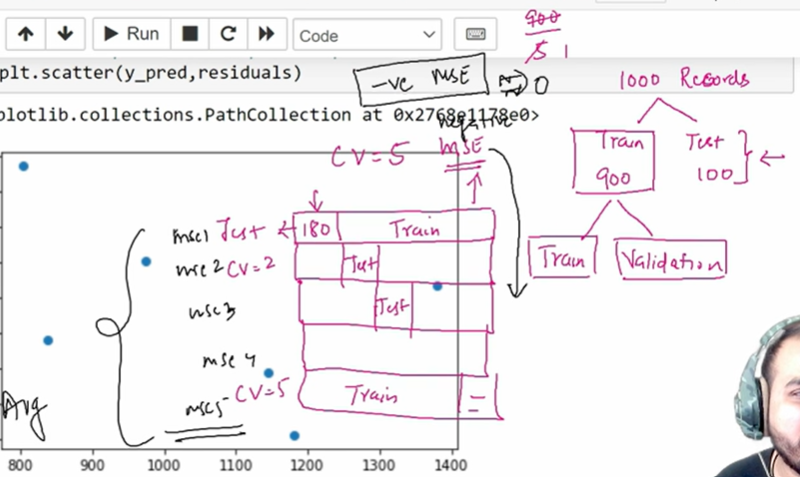

```py
## cross validation
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)
                                
```

#### x
```py
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)
#display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
```

</python>

--------------------------

1. The Default: Ascending Order
By default, rank() assigns 1 to the smallest value and N to the largest value.

Rank 1: The anime with the fewest completions (likely 0).

Rank 10,000: The most popular anime (like Fullmetal Alchemist or Death Note).

## Lec 154 Polynomial Regression Implementation

```py
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)
```

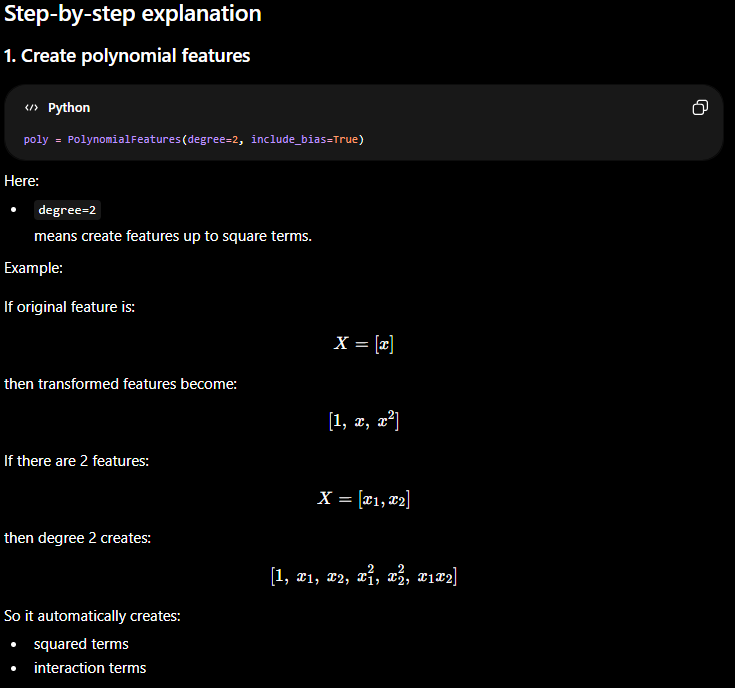
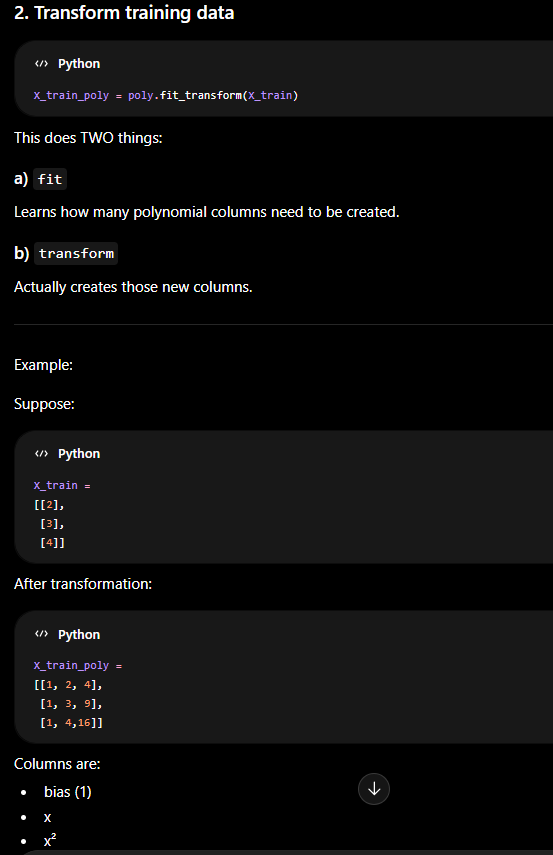
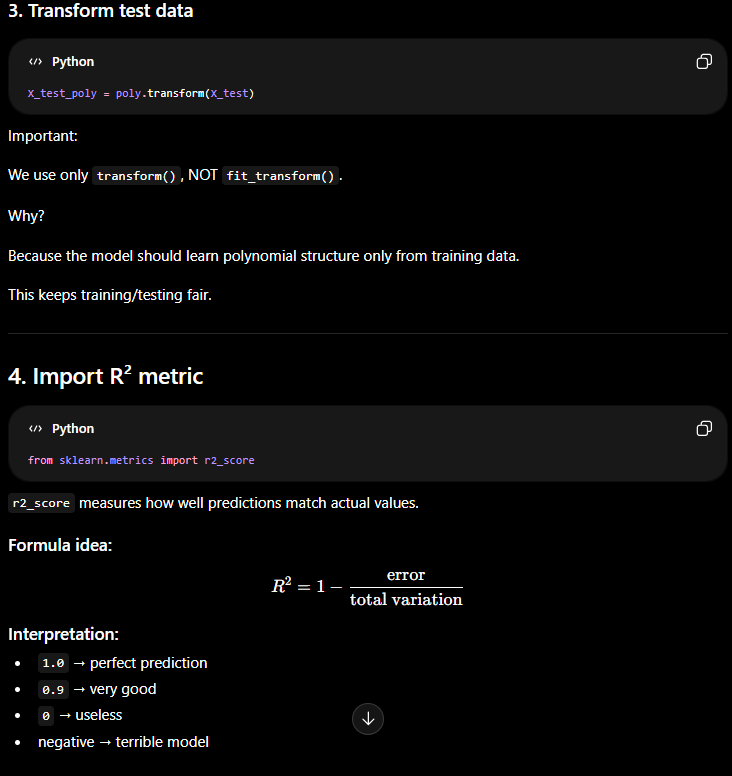
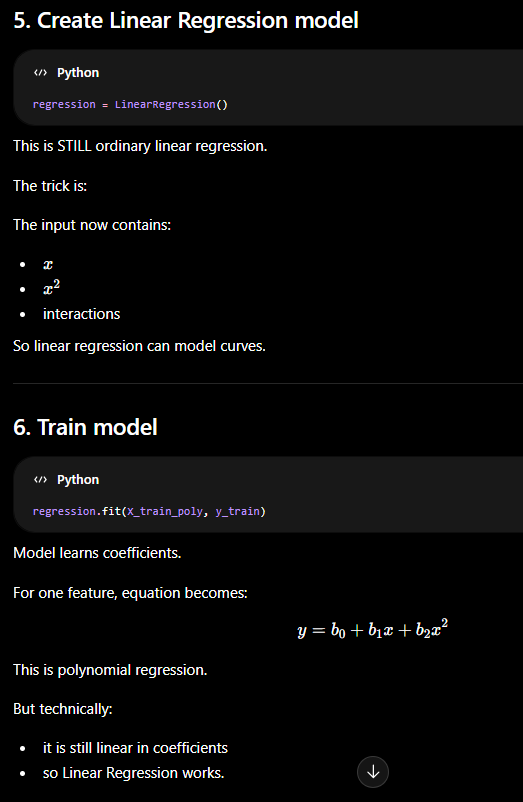
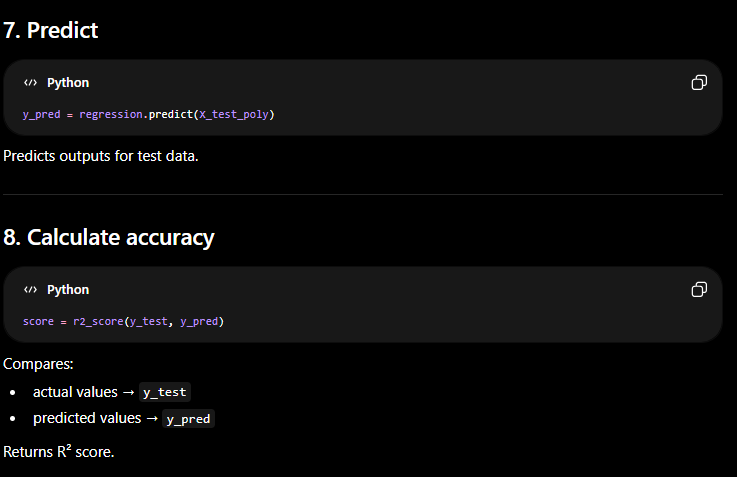
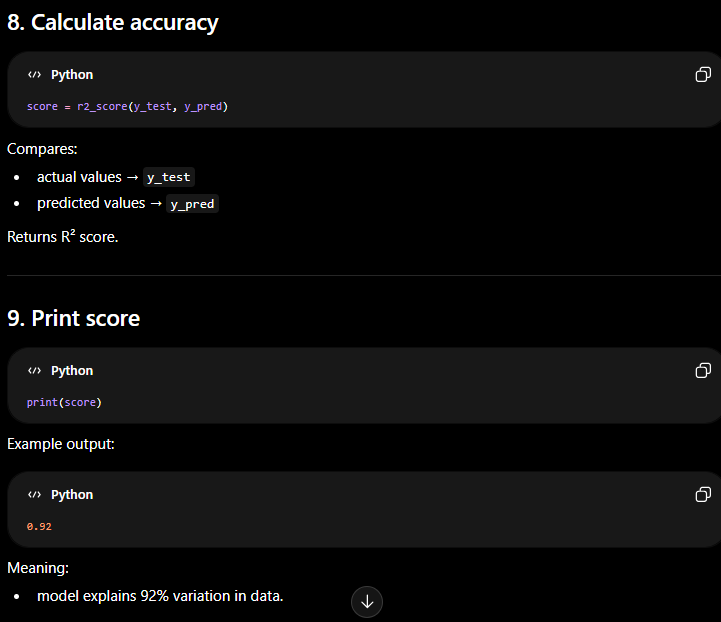



## Lec 155 Pipeline

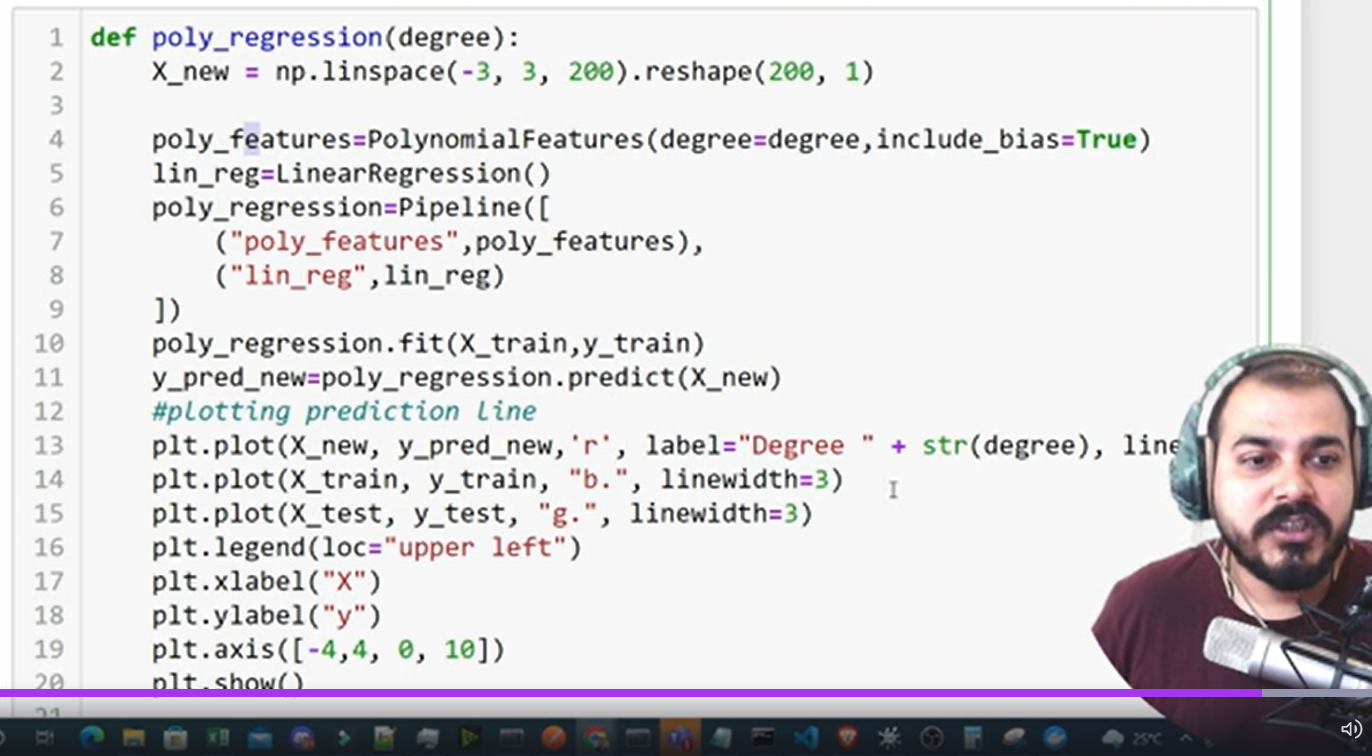

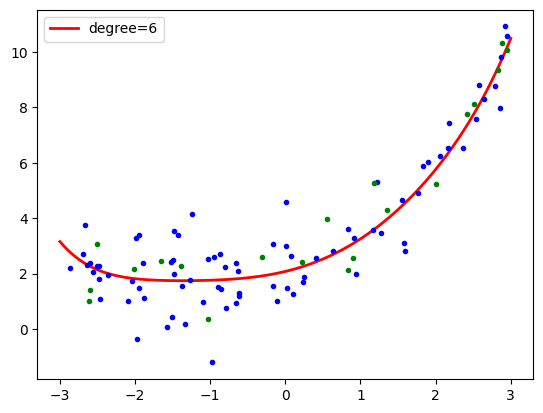

In [9]:

from sklearn.model_selection import train_test_split

# Example dataset
X = np.random.rand(100, 1) * 6 - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


def poly_regression(degree):

    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(
        degree=degree,
        include_bias=True
    )

    lin_reg = LinearRegression()

    model = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])

    model.fit(X_train, y_train)

    y_pred_new = model.predict(X_new)

    plt.plot(
        X_new,
        y_pred_new,
        'r',
        label='degree=' + str(degree),
        linewidth=2
    )

    plt.plot(X_train, y_train, 'b.', linewidth=3)
    plt.plot(X_test, y_test, 'g.', linewidth=3)

    plt.legend()
    plt.show()


poly_regression(6)

## 125. Handling Missing Values

### 1. Missing Completely at Random, MCAR:

Missing completely at random (MCAR) is a type of missing data mechanism in which the probability of a value being missing is unrelated to
both the observed data and the missing data. In other words, if the data is MCAR, the missing values are randomly distributed throughout the
dataset, and there is no systematic reason for why they are missing.

### 2. Missing at random ,MAR:
Missing at Random (MAR) is a type of missing data mechanism in which the probability of a value being missing depends only on the
observed data, but not on the missing data itself. In other words, if the data is MAR, the missing values are systematically related to the
observed data, but not to the missing data. Here are a few examples of missing at random:
Income data: Suppose you are collecting income data from a group of people, but some participants choose not to report their income. If the
decision to report or not report income is related to the participant's age or gender, but not to their income level, then the data is missing at
random.

### 3. Missing data hot at random (MNAR)
It is a type of missing data mechanism where the probability of missing values depends on the value of the missing data itself. In other words,
if the data is MNAR, the missingness is not random and is dependent on unobserved or unmeasured factors that are associated with the
missing values.

For example, suppose you are collecting data on the income and job satisfaction of employees in a company. If employees who are less
satisfied with their jobs are more likely to refuse to report their income, then the data is not missing at random. In this case, the missingness is
dependent on job satisfaction, which is not directly observed or measured.

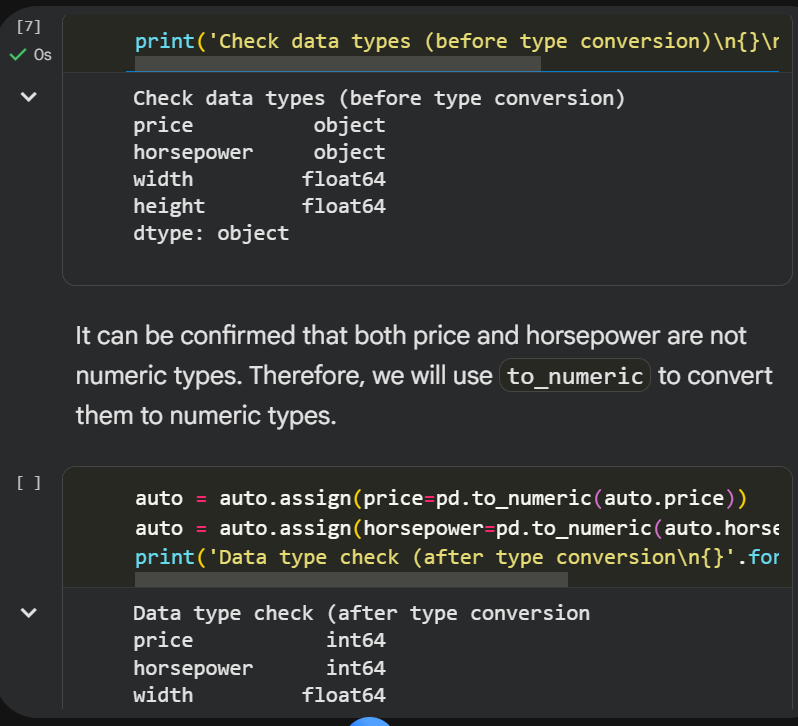

## Conversion to numeric format
4.3 Dealing Categorical Data
Next, let's convert the categorical features into numerical values so they can be used as model imputs. Most machine learning models can only accept numerical data.

Here, we will use a technique called label encoding.

```py
# Label-encode the categorical features
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))
```

## Visualizing importance of a feature in the model(here random forest)

Some machine learning models can compute the importance of the input features. Let's visualize the feature importances.`
```py
# Create a DataFrame of features and their importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
````

## Lec. 160
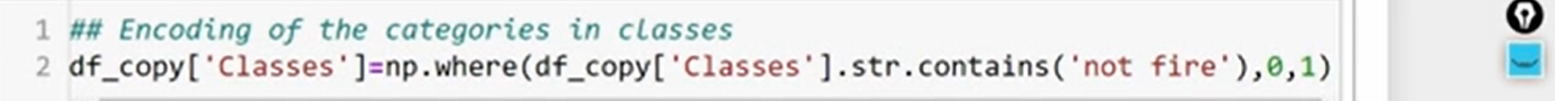

## Machine Learning Tutorial Python - 16: Hyper parameter Tuning (GridSearchCV)

[Yt video codebasics :](https://youtu.be/HdlDYng8g9s)